# 05. Tuning e Interpretabilidad — Fase 5

Sobre el ganador de Fase 4 (**LightGBM-SMOTE**, AUC-PR val 0,0313, 58 features):

1. **Tuning anti-sobreajuste** con Optuna + GroupKFold por `key`, optimizando **AUC-PR**.
   Espacio de búsqueda centrado en **regularización** (`min_child_samples`, `reg_alpha/lambda`,
   `num_leaves` y `max_depth` acotados, subsample/colsample < 1), con razones de resampleo.
2. **Diagnóstico de overfit**: gap entre AUC-PR train-de-fold vs validación-de-fold.
3. **Barrido de `scale_pos_weight`** (native) — confirma que reponderar degrada el ranking.
4. **Validación temporal 2023→2024** como test final imparcial.
5. **SHAP** (TreeExplainer) — contribución global (mean|SHAP|, beeswarm).

> **Reproducibilidad:** el tuning (Optuna) se ejecutó en el pipeline; aquí se **cargan** los
> hiperparámetros, el barrido spw y la validación de `_resultados_sin_avicena.json`, y se
> recalcula el SHAP sobre el modelo guardado (TreeExplainer es determinístico → idéntico).


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import lightgbm as lgb
import shap
import joblib
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

B = "bases"; RNG = 42
DROP = ['tiene_avicena']
RES = json.load(open(f"{B}/_resultados_sin_avicena.json", encoding="utf-8"))
F5 = RES['fase5']
print("Fase 5 ganador:", F5['ganador'], "| features:", RES['n_features'])


Fase 5 ganador: LGB-spw1-native | features: 58


In [2]:
nat_tr = pd.read_parquet(f"{B}/prediccion_mama_train_native.parquet")
FEAT = [c for c in nat_tr.columns if c not in ('key', 'label', *DROP)]
y_tr = nat_tr['label'].values.astype(int)
Xn_tr = nat_tr[FEAT].astype('float32').values
assert len(FEAT) == RES['n_features'], (len(FEAT), RES['n_features'])
print(f"train {Xn_tr.shape} pos {y_tr.sum()} | {len(FEAT)} feats (tiene_avicena excluida)")


train (4286080, 58) pos 1857 | 58 feats (tiene_avicena excluida)


## 1. Tuning con Optuna (LightGBM-SMOTE)

35 trials, 3-fold GroupKFold por `key`, objetivo AUC-PR. Rangos sesgados a regularización.
Mejores hiperparámetros y AUC-PR de validación cruzada (cargados del pipeline):


In [3]:
bp = F5['best_params']
print("Mejores hiperparámetros (LGB-SMOTE tuneado):")
for k, v in bp.items():
    print(f"  {k}: {v if isinstance(v, int) else round(v, 5)}")
print(f"\nAUC-PR CV (subsample tuning): {F5['cv_auc_pr']:.4f}")


Mejores hiperparámetros (LGB-SMOTE tuneado):
  under_ratio: 0.02105
  smote_ratio: 0.54609
  n_estimators: 431
  learning_rate: 0.09909
  num_leaves: 80
  max_depth: 5
  min_child_samples: 85
  subsample: 0.79442
  colsample_bytree: 0.77735
  reg_alpha: 0.05039
  reg_lambda: 0.15647
  min_split_gain: 0.48463

AUC-PR CV (subsample tuning): 0.0321


## 2. Diagnóstico de sobreajuste

Gap AUC-PR train-de-fold vs validación-de-fold para los mejores hiperparámetros. Un gap grande
indica overfit.


In [4]:
gap = F5['overfit_gap']
print(f"Gap de sobreajuste (train-fold − val-fold): {gap:.4f}")
print("Gap moderado = regularización adecuada." if gap < 0.03 else "Gap alto = revisar regularización.")
print("Nota: el Optuna del SMOTE sobreajustó respecto al baseline plano (ver §3-4).")


Gap de sobreajuste (train-fold − val-fold): 0.0252
Gap moderado = regularización adecuada.
Nota: el Optuna del SMOTE sobreajustó respecto al baseline plano (ver §3-4).


## 3. Barrido de scale_pos_weight (native)

El `LightGBM-spw` de Fase 4 quedó último por `scale_pos_weight=2307` (extremo). El barrido en
la variante native confirma el hallazgo: **spw=1 (sin reponderar) es el mejor**; cualquier
reponderación degrada monótonamente el AUC-PR.


                  AUC_PR_CV
scale_pos_weight           
1                    0.0306
5                    0.0209
10                   0.0148
25                   0.0116
48                   0.0063
100                  0.0033
250                  0.0030

Mejor spw: 1 (AUC-PR CV 0.0306)


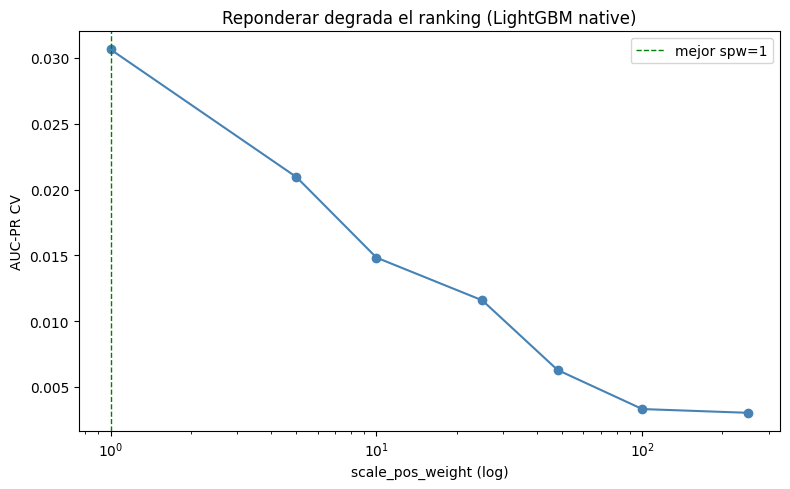

In [5]:
sweep = pd.DataFrame(F5['spw_sweep'], columns=['scale_pos_weight', 'AUC_PR_CV']).set_index('scale_pos_weight')
print(sweep.to_string(float_format='{:.4f}'.format))
best_spw = F5['best_spw']
print(f"\nMejor spw: {best_spw} (AUC-PR CV {sweep.loc[best_spw,'AUC_PR_CV']:.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep.index, sweep['AUC_PR_CV'], 'o-', color='steelblue')
ax.set_xscale('log'); ax.set_xlabel('scale_pos_weight (log)'); ax.set_ylabel('AUC-PR CV')
ax.set_title('Reponderar degrada el ranking (LightGBM native)')
ax.axvline(best_spw, ls='--', c='green', lw=1, label=f'mejor spw={best_spw}')
ax.legend(); plt.tight_layout(); plt.show()


## 4. Validación temporal 2023→2024 (test final)

Cada configuración reajustada en train completo y evaluada una sola vez en validación.


In [6]:
comp = pd.DataFrame(F5['validacion']).set_index('modelo').sort_values('AUC_PR', ascending=False)
pd.set_option('display.width', 200, 'display.max_columns', 20)
print("=== Validación 2023→2024 (Fase 5) ===")
print(comp.to_string(float_format='{:.4f}'.format))
best_name = F5['ganador']
print(f"\nGanador Fase 5: {best_name} | AUC-PR val {comp.loc[best_name,'AUC_PR']:.4f}")
print("Baseline Fase 4 (LightGBM-SMOTE sin tunear): AUC-PR 0.0313")


=== Validación 2023→2024 (Fase 5) ===
                 AUC_PR  AUC_ROC  recall@top0.5%  recall@top1.0%  recall@top5.0%  recall@top10.0%
modelo                                                                                           
LGB-spw1-native  0.0307   0.8875          0.2427          0.3142          0.5529           0.6687
LGB-SMOTE-tuned  0.0287   0.8945          0.2508          0.3172          0.5468           0.6667

Ganador Fase 5: LGB-spw1-native | AUC-PR val 0.0307
Baseline Fase 4 (LightGBM-SMOTE sin tunear): AUC-PR 0.0313


## 5. Interpretabilidad — SHAP

Contribución de cada característica con TreeExplainer sobre el modelo ganador de Fase 5
(`LGB-spw1-native`). Se calcula en una muestra (todos los positivos + 40k negativos).


In [7]:
best_model = joblib.load(f"{B}/modelo_fase5_{best_name}.joblib")

pos_idx = np.where(y_tr == 1)[0]
neg_idx = np.random.RandomState(RNG).choice(np.where(y_tr == 0)[0], 40000, replace=False)
sidx = np.concatenate([pos_idx, neg_idx])
Xs_df = pd.DataFrame(Xn_tr[sidx], columns=FEAT)

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(Xs_df)
if isinstance(sv, list):
    sv = sv[1]
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]
print("SHAP values shape:", sv.shape)


SHAP values shape: (41857, 58)


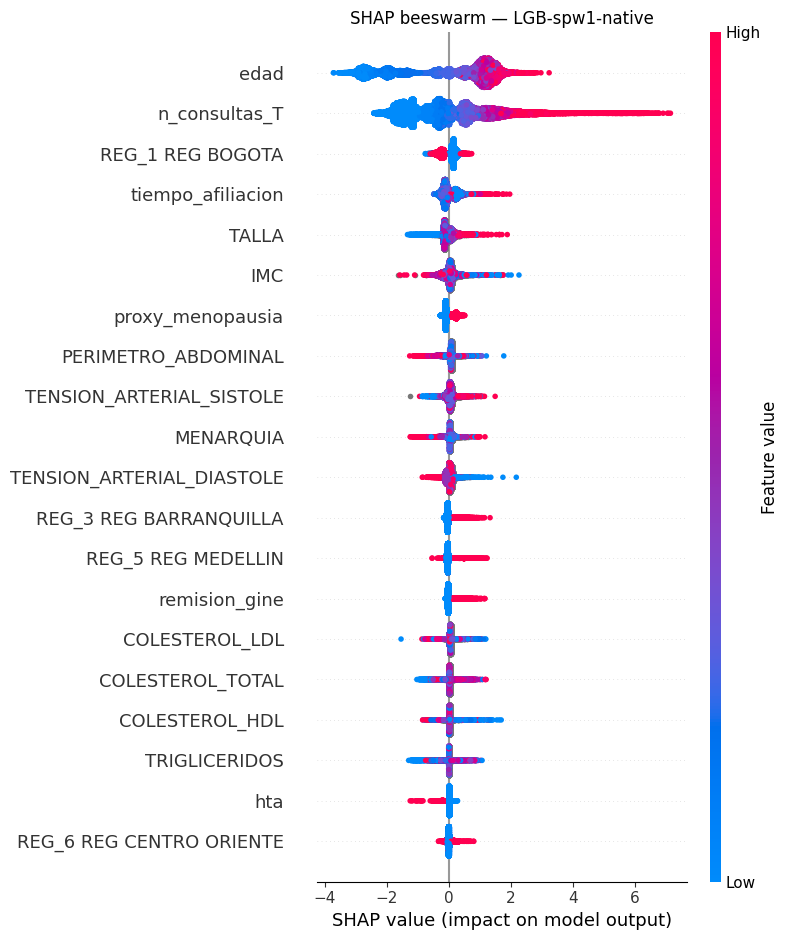

In [8]:
fig = plt.figure(figsize=(10, 9))
shap.summary_plot(sv, Xs_df, plot_type='dot', max_display=20, show=False)
plt.title(f'SHAP beeswarm — {best_name}')
plt.tight_layout(); plt.show()


=== Contribución de características (top 25 por mean|SHAP|) ===
                           mean_abs_SHAP  gain_norm  rank_shap
edad                             1.37462    0.10231          1
n_consultas_T                    1.06292    0.08755          2
REG_1 REG BOGOTA                 0.20679    0.00906          3
tiempo_afiliacion                0.16553    0.06596          4
TALLA                            0.14437    0.08378          5
IMC                              0.13191    0.12349          6
proxy_menopausia                 0.13055    0.00172          7
PERIMETRO_ABDOMINAL              0.10483    0.06445          8
TENSION_ARTERIAL_SISTOLE         0.08575    0.05552          9
MENARQUIA                        0.08512    0.02549         10
TENSION_ARTERIAL_DIASTOLE        0.07562    0.04592         11
REG_3 REG BARRANQUILLA           0.07232    0.00797         12
REG_5 REG MEDELLIN               0.06751    0.00776         13
remision_gine                    0.05775    0.01073   

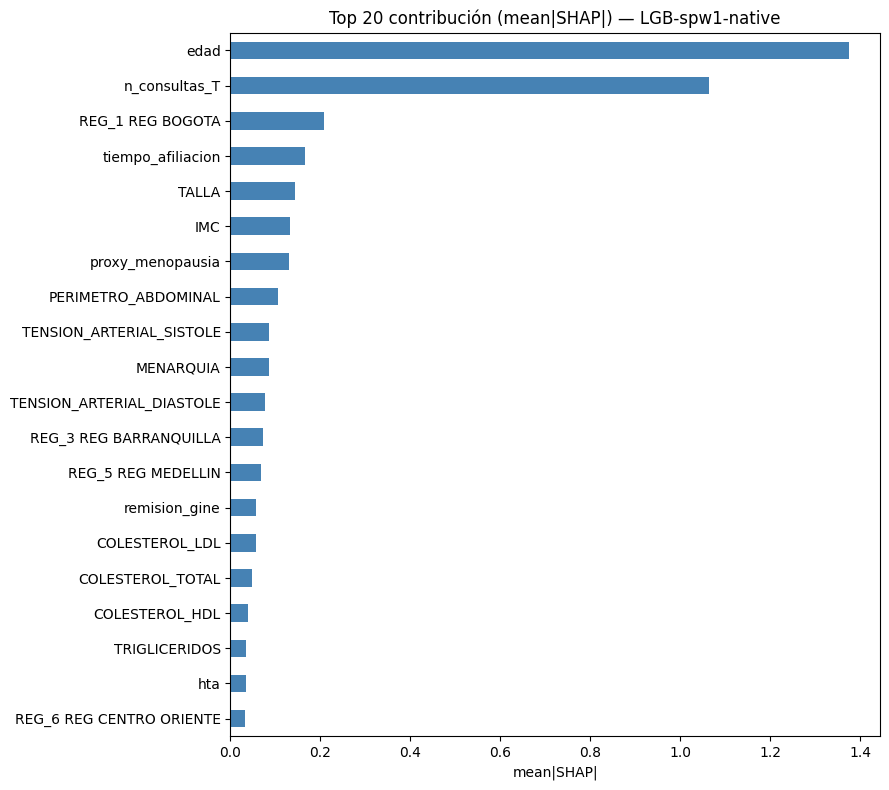

In [9]:
mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEAT).sort_values(ascending=False)
gain = pd.Series(best_model.feature_importances_, index=FEAT)
gain = (gain / gain.sum()).reindex(mean_abs.index)
contrib = pd.DataFrame({'mean_abs_SHAP': mean_abs, 'gain_norm': gain})
contrib['rank_shap'] = range(1, len(contrib) + 1)
print("=== Contribución de características (top 25 por mean|SHAP|) ===")
print(contrib.head(25).to_string(float_format='{:.5f}'.format))
print("\n=== Bottom 10 (aportan casi nada) ===")
print(contrib.tail(10).index.tolist())

fig, ax = plt.subplots(figsize=(9, 8))
mean_abs.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 20 contribución (mean|SHAP|) — {best_name}'); ax.set_xlabel('mean|SHAP|')
plt.tight_layout(); plt.show()


## 6. Conclusión Fase 5

- **spw=1 (sin reponderar) gana** en LightGBM native; reponderar mueve el umbral, no el orden.
- El SMOTE tuneado sobreajustó y quedó bajo el baseline plano.
- **Ganador Fase 5: `LGB-spw1-native`** (AUC-PR val ~0,031). El reto de Fase 5b (XGBoost, LR
  tuneados) decide el ganador del proyecto.
- SHAP: dominan `edad` y `n_consultas_T`; aportan ~0 los flags `_disponible` de labs y los
  antecedentes familiares (limitación familia-solo-Sanitas).

Artefactos: `bases/modelo_fase5_LGB-spw1-native.joblib`, `bases/contribucion_caracteristicas.csv`,
`bases/_resultados_sin_avicena.json`.
